<a href="https://colab.research.google.com/github/tulangsodimha/TULANGSO/blob/TULANGSO/notebooks/Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

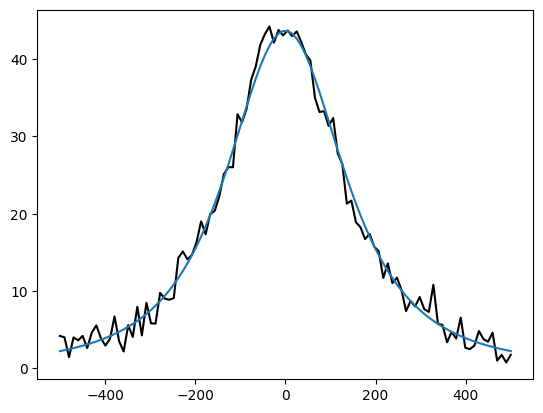

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import openpyxl
df = pd.read_excel(r"gravity_data.xlsx", sheet_name=None)
data_1 = df['With_Noise']
data_2 = df['Without_Noise']



plt.plot(data_1['Distance (m)'],data_1['Gravity (mGal)'],"k-",label="without noise")
plt.plot(data_2['Distance (m)'], data_2['Gravity (mGal)'])
plt.show()


Estimated Density Contrast (Noisy Data): 50172962.29480541
Estimated Density Contrast (Clean Data): 49999999.99999999


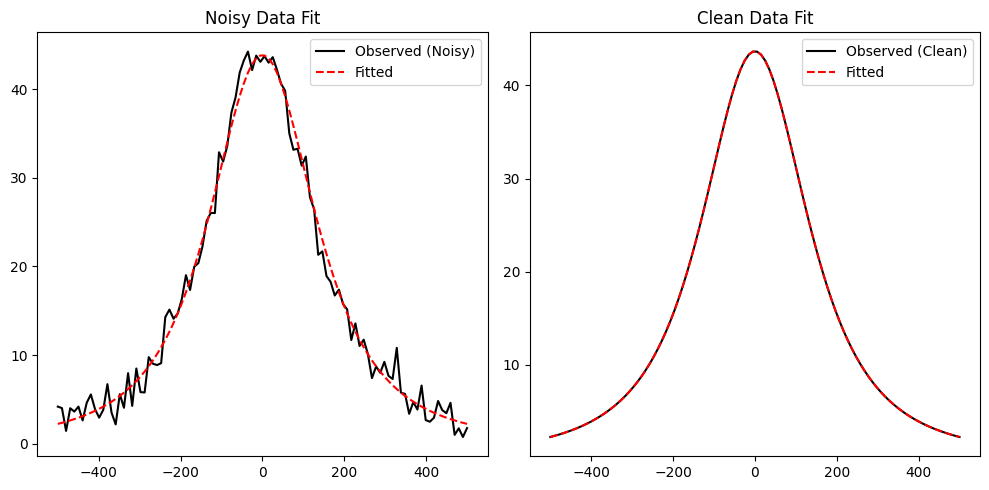

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("gravity_data.xlsx", sheet_name=None)
data_noise = df['With_Noise']
data_clean = df['Without_Noise']

# Extract values
x1 = data_noise['Distance (m)'].values
g1 = data_noise['Gravity (mGal)'].values

x2 = data_clean['Distance (m)'].values
g2 = data_clean['Gravity (mGal)'].values

# Constants
G_const = 6.674e-11
R = 500
z = 200
q = 1.5

# Build A(x)
def compute_A(x):
    return (4/3) * np.pi * G_const * (R**3) * (z / ((x**2 + z**2)**q))

A1 = compute_A(x1)
A2 = compute_A(x2)

# Least squares estimation
sigma_noise = np.sum(A1 * g1) / np.sum(A1**2)
sigma_clean = np.sum(A2 * g2) / np.sum(A2**2)

print("Estimated Density Contrast (Noisy Data):", sigma_noise)
print("Estimated Density Contrast (Clean Data):", sigma_clean)

# Predicted gravity
g1_pred = A1 * sigma_noise
g2_pred = A2 * sigma_clean

# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(x1, g1, 'k-', label="Observed (Noisy)")
plt.plot(x1, g1_pred, 'r--', label="Fitted")
plt.title("Noisy Data Fit")
plt.legend()

plt.subplot(1,2,2)
plt.plot(x2, g2, 'k-', label="Observed (Clean)")
plt.plot(x2, g2_pred, 'r--', label="Fitted")
plt.title("Clean Data Fit")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("gravity_data.xlsx", sheet_name=None)
data_noise = df['With_Noise']
data_clean = df['Without_Noise']

# Extract values
x1 = data_noise['Distance (m)'].values
g1 = data_noise['Gravity (mGal)'].values * 1e-5   # 🔥 converted

x2 = data_clean['Distance (m)'].values
g2 = data_clean['Gravity (mGal)'].values * 1e-5   # 🔥 converted

# Constants
G_const = 6.674e-11
R = 500
z = 200
q = 1.5

# Build A(x)
def compute_A(x):
    return (4/3) * np.pi * G_const * (R**3) * (z / ((x**2 + z**2)**q))

A1 = compute_A(x1)
A2 = compute_A(x2)

# Least squares estimation
sigma_noise = np.sum(A1 * g1) / np.sum(A1**2)
sigma_clean = np.sum(A2 * g2) / np.sum(A2**2)

print("Estimated Density Contrast (Noisy Data):", sigma_noise)
print("Estimated Density Contrast (Clean Data):", sigma_clean)

Estimated Density Contrast (Noisy Data): 501.72962294805416
Estimated Density Contrast (Clean Data): 499.99999999999994


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("gravity_data.xlsx", sheet_name=None)
data_noise = df['With_Noise']
data_clean = df['Without_Noise']

# Extract values (convert to SI)
x1 = data_noise['Distance (m)'].values
g1 = data_noise['Gravity (mGal)'].values * 1e-5

x2 = data_clean['Distance (m)'].values
g2 = data_clean['Gravity (mGal)'].values * 1e-5

# Constants
G_const = 6.674e-11
R = 500
q = 1.5

# Model function
def gravity_model(x, z, sigma):
    A = (4/3) * np.pi * G_const * (R**3) * (z / ((x**2 + z**2)**q))
    return sigma * A

# Grid range
z_range = np.linspace(100, 1000, 50)        # depth
sigma_range = np.linspace(100, 1000, 50)    # density contrast

# Function to find best model
def grid_search(x, g_obs):
    best_error = np.inf
    best_z = None
    best_sigma = None

    for z in z_range:
        for sigma in sigma_range:
            g_pred = gravity_model(x, z, sigma)
            error = np.sum((g_obs - g_pred)**2)

            if error < best_error:
                best_error = error
                best_z = z
                best_sigma = sigma

    return best_z, best_sigma, best_error

# Run for noisy and clean data
z_noise, sigma_noise, err1 = grid_search(x1, g1)
z_clean, sigma_clean, err2 = grid_search(x2, g2)

print("Noisy Data → Depth:", z_noise, "Density:", sigma_noise)
print("Clean Data → Depth:", z_clean, "Density:", sigma_clean)

Noisy Data → Depth: 191.83673469387756 Density: 467.34693877551024
Clean Data → Depth: 191.83673469387756 Density: 467.34693877551024


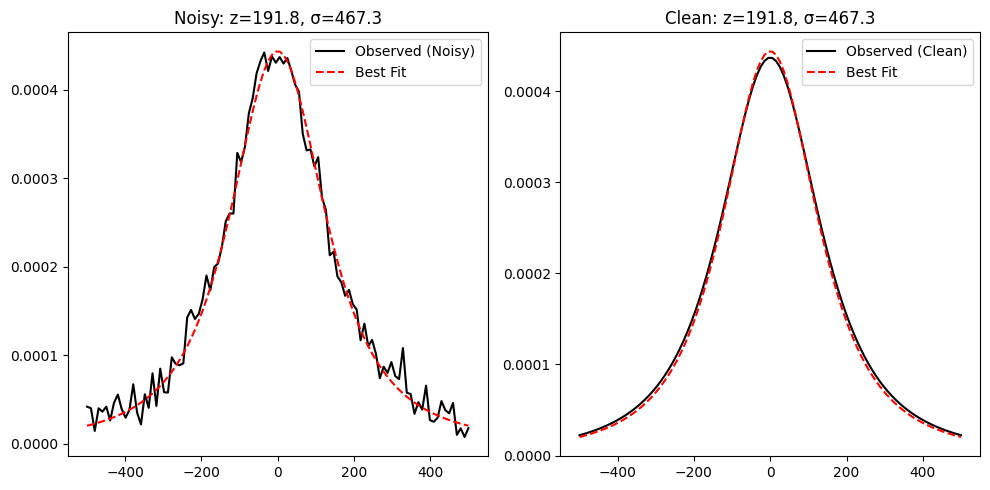

In [14]:
# Predicted curves
g1_pred = gravity_model(x1, z_noise, sigma_noise)
g2_pred = gravity_model(x2, z_clean, sigma_clean)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(x1, g1, 'k-', label="Observed (Noisy)")
plt.plot(x1, g1_pred, 'r--', label="Best Fit")
plt.title(f"Noisy: z={z_noise:.1f}, σ={sigma_noise:.1f}")
plt.legend()

plt.subplot(1,2,2)
plt.plot(x2, g2, 'k-', label="Observed (Clean)")
plt.plot(x2, g2_pred, 'r--', label="Best Fit")
plt.title(f"Clean: z={z_clean:.1f}, σ={sigma_clean:.1f}")
plt.legend()

plt.tight_layout()
plt.show()

---- Noisy Data ----
Iter 1: z=-80.02, sigma=324.52
Iter 2: z=-57.16, sigma=-251.63
Iter 3: z=-72.03, sigma=-159.68
Iter 4: z=-110.14, sigma=-220.14
Iter 5: z=-164.13, sigma=-356.55
Iter 6: z=-194.80, sigma=-470.96
Iter 7: z=-197.35, sigma=-491.49
Iter 8: z=-197.36, sigma=-491.79
Iter 9: z=-197.36, sigma=-491.79
Iter 10: z=-197.36, sigma=-491.79

---- Clean Data ----
Iter 1: z=-75.15, sigma=329.77
Iter 2: z=-55.09, sigma=-231.92
Iter 3: z=-69.77, sigma=-149.63
Iter 4: z=-107.86, sigma=-210.04
Iter 5: z=-164.41, sigma=-351.95
Iter 6: z=-198.02, sigma=-478.32
Iter 7: z=-200.05, sigma=-499.93
Iter 8: z=-200.00, sigma=-500.00
Iter 9: z=-200.00, sigma=-500.00
Iter 10: z=-200.00, sigma=-500.00


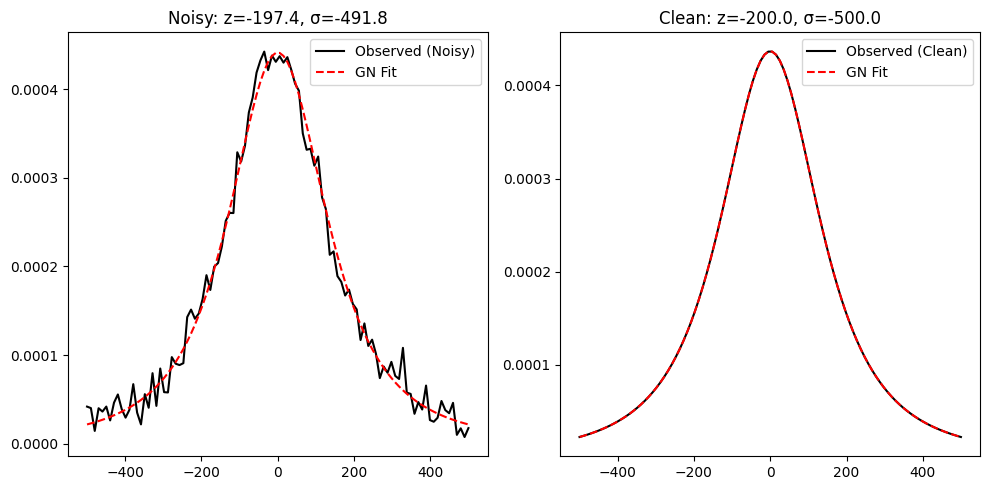

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("gravity_data.xlsx", sheet_name=None)
data_noise = df['With_Noise']
data_clean = df['Without_Noise']

# Extract (convert to SI)
x1 = data_noise['Distance (m)'].values
g1 = data_noise['Gravity (mGal)'].values * 1e-5

x2 = data_clean['Distance (m)'].values
g2 = data_clean['Gravity (mGal)'].values * 1e-5

# Constants
G_const = 6.674e-11
R = 500
C = (4/3) * np.pi * G_const * (R**3)

# Forward model
def forward(x, z, sigma):
    return sigma * C * (z / ((x**2 + z**2)**1.5))

# Jacobian
def jacobian(x, z, sigma):
    denom = (x**2 + z**2)

    A = C * (z / (denom**1.5))  # ∂g/∂σ

    dgdZ = sigma * C * (
        (1 / (denom**1.5)) - (3 * z**2 / (denom**2.5))
    )

    J = np.vstack((dgdZ, A)).T   # [∂g/∂z , ∂g/∂σ]
    return J

# Gauss-Newton function
def gauss_newton(x, g_obs, z0=300, sigma0=300, n_iter=10):
    z = z0
    sigma = sigma0

    for i in range(n_iter):
        g_pred = forward(x, z, sigma)
        r = g_obs - g_pred

        J = jacobian(x, z, sigma)

        # Solve normal equation
        dm = np.linalg.inv(J.T @ J) @ J.T @ r

        z += dm[0]
        sigma += dm[1]

        print(f"Iter {i+1}: z={z:.2f}, sigma={sigma:.2f}")

    return z, sigma

# Run inversion
print("---- Noisy Data ----")
z_noise, sigma_noise = gauss_newton(x1, g1)

print("\n---- Clean Data ----")
z_clean, sigma_clean = gauss_newton(x2, g2)

# Plot fit
g1_pred = forward(x1, z_noise, sigma_noise)
g2_pred = forward(x2, z_clean, sigma_clean)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(x1, g1, 'k-', label="Observed (Noisy)")
plt.plot(x1, g1_pred, 'r--', label="GN Fit")
plt.title(f"Noisy: z={z_noise:.1f}, σ={sigma_noise:.1f}")
plt.legend()

plt.subplot(1,2,2)
plt.plot(x2, g2, 'k-', label="Observed (Clean)")
plt.plot(x2, g2_pred, 'r--', label="GN Fit")
plt.title(f"Clean: z={z_clean:.1f}, σ={sigma_clean:.1f}")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
def gauss_newton_with_residual(x, g_obs, z0=300, sigma0=300, n_iter=10):
    z = z0
    sigma = sigma0

    errors = []   # 🔥 store residuals

    for i in range(n_iter):
        g_pred = forward(x, z, sigma)
        r = g_obs - g_pred

        error = np.sum(r**2)
        errors.append(error)

        J = jacobian(x, z, sigma)
        dm = np.linalg.inv(J.T @ J) @ J.T @ r

        z += dm[0]
        sigma += dm[1]

        print(f"Iter {i+1}: z={z:.2f}, sigma={sigma:.2f}, Error={error:.3e}")

    return z, sigma, errors

In [19]:
z_noise, sigma_noise, err_noise = gauss_newton_with_residual(x1, g1)
z_clean, sigma_clean, err_clean = gauss_newton_with_residual(x2, g2)

Iter 1: z=-80.02, sigma=324.52, Error=2.137e-06
Iter 2: z=-57.16, sigma=-251.63, Error=5.405e-05
Iter 3: z=-72.03, sigma=-159.68, Error=2.919e-05
Iter 4: z=-110.14, sigma=-220.14, Error=2.845e-06
Iter 5: z=-164.13, sigma=-356.55, Error=5.236e-07
Iter 6: z=-194.80, sigma=-470.96, Error=7.417e-08
Iter 7: z=-197.35, sigma=-491.49, Error=2.508e-08
Iter 8: z=-197.36, sigma=-491.79, Error=2.241e-08
Iter 9: z=-197.36, sigma=-491.79, Error=2.241e-08
Iter 10: z=-197.36, sigma=-491.79, Error=2.241e-08
Iter 1: z=-75.15, sigma=329.77, Error=2.091e-06
Iter 2: z=-55.09, sigma=-231.92, Error=6.304e-05
Iter 3: z=-69.77, sigma=-149.63, Error=2.774e-05
Iter 4: z=-107.86, sigma=-210.04, Error=2.850e-06
Iter 5: z=-164.41, sigma=-351.95, Error=5.452e-07
Iter 6: z=-198.02, sigma=-478.32, Error=6.227e-08
Iter 7: z=-200.05, sigma=-499.93, Error=3.845e-09
Iter 8: z=-200.00, sigma=-500.00, Error=1.160e-12
Iter 9: z=-200.00, sigma=-500.00, Error=1.266e-19
Iter 10: z=-200.00, sigma=-500.00, Error=3.514e-33


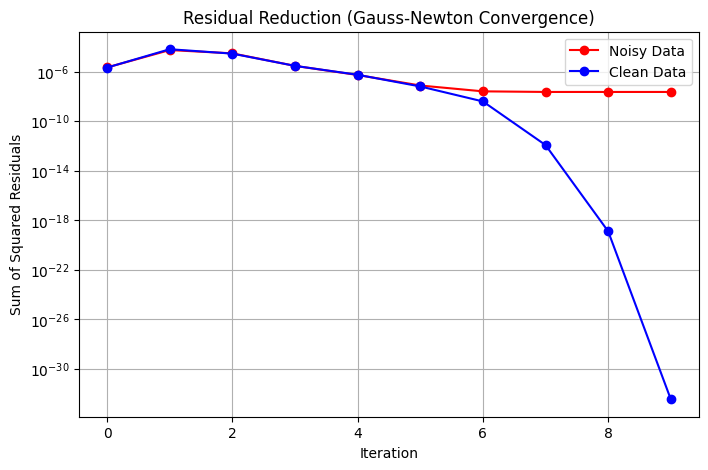

In [20]:
plt.figure(figsize=(8,5))

plt.plot(err_noise, 'ro-', label="Noisy Data")
plt.plot(err_clean, 'bo-', label="Clean Data")

plt.xlabel("Iteration")
plt.ylabel("Sum of Squared Residuals")
plt.title("Residual Reduction (Gauss-Newton Convergence)")
plt.yscale('log')   # 🔥 IMPORTANT (better visualization)
plt.legend()

plt.grid()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

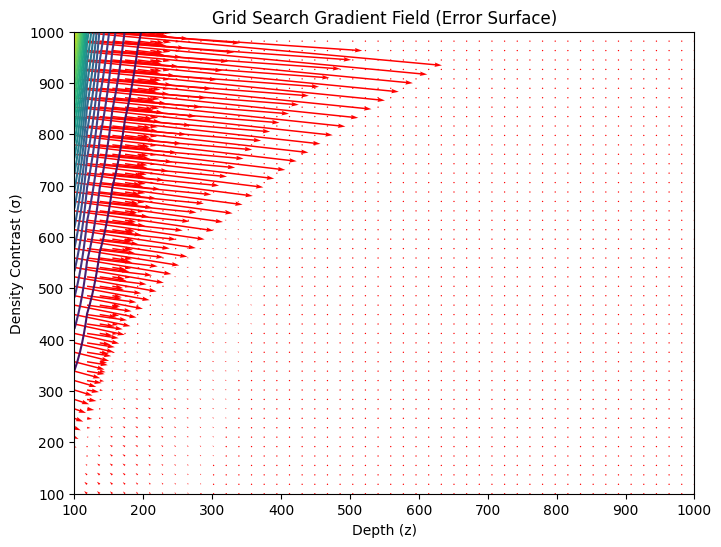

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Use same forward model
def gravity_model(x, z, sigma):
    G_const = 6.674e-11
    R = 500
    C = (4/3) * np.pi * G_const * (R**3)
    return sigma * C * (z / ((x**2 + z**2)**1.5))

# Grid
z_vals = np.linspace(100, 1000, 50)
sigma_vals = np.linspace(100, 1000, 50)

Z, S = np.meshgrid(z_vals, sigma_vals)

# Compute error surface (use clean or noisy data)
E = np.zeros_like(Z)

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        g_pred = gravity_model(x2, Z[i,j], S[i,j])   # use clean data (x2, g2)
        E[i,j] = np.sum((g2 - g_pred)**2)

# Compute gradients
dE_dsigma, dE_dz = np.gradient(E, sigma_vals, z_vals)

# Plot
plt.figure(figsize=(8,6))

# Contour
plt.contour(Z, S, E, levels=20)

# Gradient vectors
plt.quiver(Z, S, -dE_dz, -dE_dsigma, color='r')
# negative → direction of minimum

plt.xlabel("Depth (z)")
plt.ylabel("Density Contrast (σ)")
plt.title("Grid Search Gradient Field (Error Surface)")

plt.show()